In [44]:
import pandas as pd

In [94]:
def process_data(diann_path, mumdia_path, pin_path, peptide_level=False):
    """
    Process DIA-NN and MuMDIA data for comparison.

    Args:
        diann_path: Path to DIA-NN parquet file
        mumdia_path: Path to MuMDIA mokapot.psms.txt file
        pin_path: Path to pin file

    Returns:
        tuple: (diann_data, mumdia_merged_data)
    """

    modification_mapper = {"(UniMod:35)": "[Oxidation]", "(UniMod:4)": ""}
    # Load DIA-NN data
    diann_data = pd.read_parquet(diann_path)

    for old, new in modification_mapper.items():
        diann_data["Modified.Sequence"] = diann_data["Modified.Sequence"].str.replace(
            old, new, regex=False
        )
        diann_data["Precursor.Id"] = diann_data["Precursor.Id"].str.replace(
            old, new, regex=False
        )

    # Load MuMDIA data
    mumdia_data = pd.read_csv(mumdia_path, sep="\t")
    mumdia_valid = mumdia_data[
        (mumdia_data["mokapot q-value"] <= 0.01) & (mumdia_data["Label"])
    ]
    print("Mumdia shape:", mumdia_valid.shape)
    pin_data = pd.read_csv(pin_path, sep="\t")

    # Merge and filter MuMDIA data
    mumdia_merged = pd.merge(
        mumdia_valid,
        pin_data[["ScanNr", "filename", "charge"]],
        on=["filename", "ScanNr"],
        how="left",
    )
    print("mumdia_merged shape:", mumdia_merged.shape)

    # Create Precursor.Id for MuMDIA data
    mumdia_merged["Precursor.Id"] = mumdia_merged["Peptide"] + mumdia_merged[
        "charge"
    ].astype(int).astype(str)

    return diann_data, mumdia_merged

# Astral

In [46]:
# Process Astral data
diann_astral, mumdia_astral_valid = process_data(
    "/home/robbe/MuMDIA/DIA-NN_output/Astral_no_mods/report.parquet",
    "/home/robbe/MuMDIA/results/astral/mokapot.psms.txt",
    "/home/robbe/MuMDIA/results/astral/outfile.pin",
)

Mumdia shape: (25471, 11)
mumdia_merged shape: (25471, 12)
mumdia_merged shape: (25471, 12)


# Data Processing and Comparison

Process both Astral and TimsTOF datasets and create comparative visualizations.

In [47]:
# Process TimsTOF data
diann_timsconvert, mumdia_timsconvert_valid = process_data(
    "/home/robbe/MuMDIA/DIA-NN_output/timsconvert/report.parquet",
    "/home/robbe/MuMDIA/results/timsconvert/mokapot.psms.txt",
    "/home/robbe/MuMDIA/results/timsconvert/outfile.pin",
)

Mumdia shape: (7076, 11)
mumdia_merged shape: (7076, 12)
mumdia_merged shape: (7076, 12)


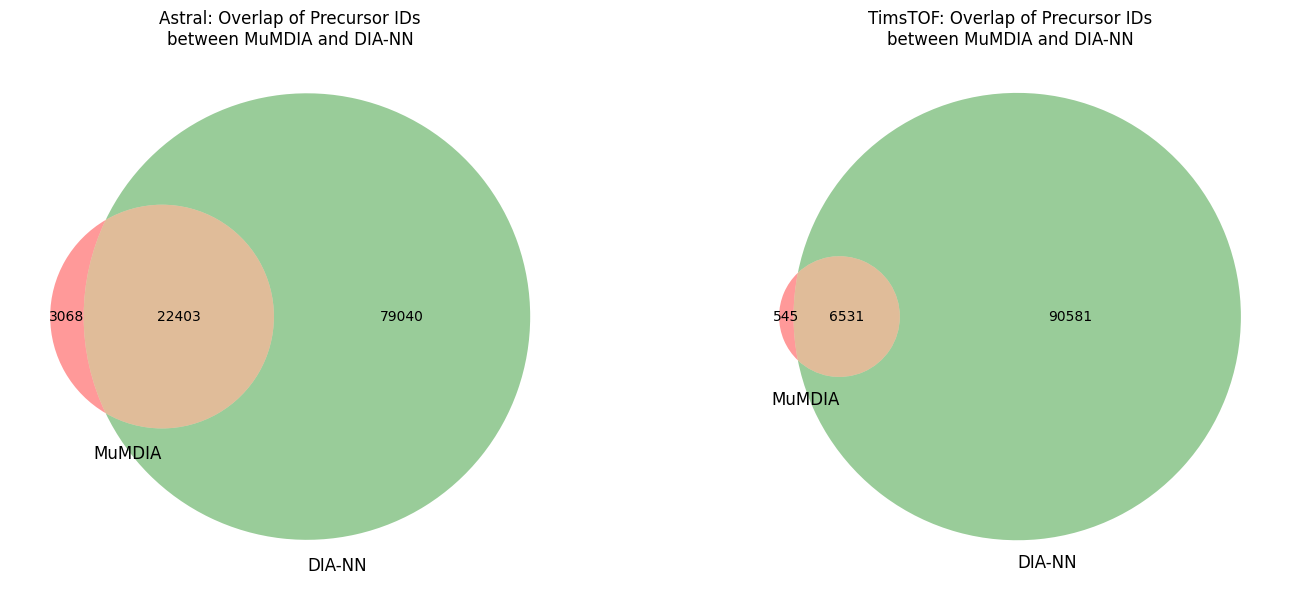

Astral Dataset:
  MuMDIA identifications: 25471
  DIA-NN identifications: 101443
  Overlap: 22403
  MuMDIA unique: 3068
  DIA-NN unique: 79040

TimsTOF Dataset:
  MuMDIA identifications: 7076
  DIA-NN identifications: 97112
  Overlap: 6531
  MuMDIA unique: 545
  DIA-NN unique: 90581


In [48]:
# Create subfigures showing Venn diagrams for both datasets
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Astral Venn diagram
plt.sca(ax1)
mumdia_precursor_ids_astral = set(mumdia_astral_valid["Precursor.Id"])
diann_precursor_ids_astral = set(diann_astral["Precursor.Id"])
venn2(
    [mumdia_precursor_ids_astral, diann_precursor_ids_astral],
    set_labels=("MuMDIA", "DIA-NN"),
    ax=ax1,
)
ax1.set_title("Astral: Overlap of Precursor IDs\nbetween MuMDIA and DIA-NN")

# TimsTOF Venn diagram
plt.sca(ax2)
mumdia_precursor_ids_timsconvert = set(mumdia_timsconvert_valid["Precursor.Id"])
diann_precursor_ids_timsconvert = set(diann_timsconvert["Precursor.Id"])
venn2(
    [mumdia_precursor_ids_timsconvert, diann_precursor_ids_timsconvert],
    set_labels=("MuMDIA", "DIA-NN"),
    ax=ax2,
)
ax2.set_title("TimsTOF: Overlap of Precursor IDs\nbetween MuMDIA and DIA-NN")

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Astral Dataset:")
print(f"  MuMDIA identifications: {len(mumdia_precursor_ids_astral)}")
print(f"  DIA-NN identifications: {len(diann_precursor_ids_astral)}")
print(f"  Overlap: {len(mumdia_precursor_ids_astral & diann_precursor_ids_astral)}")
print(
    f"  MuMDIA unique: {len(mumdia_precursor_ids_astral - diann_precursor_ids_astral)}"
)
print(
    f"  DIA-NN unique: {len(diann_precursor_ids_astral - mumdia_precursor_ids_astral)}"
)

print(f"\nTimsTOF Dataset:")
print(f"  MuMDIA identifications: {len(mumdia_precursor_ids_timsconvert)}")
print(f"  DIA-NN identifications: {len(diann_precursor_ids_timsconvert)}")
print(
    f"  Overlap: {len(mumdia_precursor_ids_timsconvert & diann_precursor_ids_timsconvert)}"
)
print(
    f"  MuMDIA unique: {len(mumdia_precursor_ids_timsconvert - diann_precursor_ids_timsconvert)}"
)
print(
    f"  DIA-NN unique: {len(diann_precursor_ids_timsconvert - mumdia_precursor_ids_timsconvert)}"
)

# ECOLI

In [88]:
# Process Astral data
diann_astral, mumdia_astral_valid = process_data(
    "/home/robbe/MuMDIA/DIA-NN_output/ecoli/report.parquet",
    "/home/robbe/MuMDIA/results/config_playing/mokapot.psms.txt",
    "/home/robbe/MuMDIA/results/config_playing/outfile.pin",
)

Mumdia shape: (10452, 11)
mumdia_merged shape: (10452, 12)


In [89]:
diann_astral

,Run.Index,Run,Channel,Precursor.Id,Modified.Sequence,Stripped.Sequence,Precursor.Charge,Precursor.Lib.Index,Decoy,Proteotypic,...,Translated.Q.Value,Channel.Q.Value,PG.Q.Value,PG.PEP,GG.Q.Value,Protein.Q.Value,Global.PG.Q.Value,Lib.PG.Q.Value,Best.Fr.Mz,Best.Fr.Mz.Delta
0,0,LFQ_Orbitrap_AIF_Ecoli_01,,AAAAEIAVK2,AAAAEIAVK,AAAAEIAVK,2,10,0,1,...,0.0,0.0,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,317.218323,0.000641
1,0,LFQ_Orbitrap_AIF_Ecoli_01,,AAAAPVTGPLADDPIQETITFDDFAK3,AAAAPVTGPLADDPIQETITFDDFAK,AAAAPVTGPLADDPIQETITFDDFAK,3,58,0,1,...,0.0,0.0,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,214.118622,0.001190
2,0,LFQ_Orbitrap_AIF_Ecoli_01,,AAAAVLAK1,AAAAVLAK,AAAAVLAK,1,72,0,1,...,0.0,0.0,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,384.224152,-0.000183
3,0,LFQ_Orbitrap_AIF_Ecoli_01,,AAADLISR2,AAADLISR,AAADLISR,2,107,0,1,...,0.0,0.0,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,603.346069,-0.000244
4,0,LFQ_Orbitrap_AIF_Ecoli_01,,AAADVQLR2,AAADVQLR,AAADVQLR,2,116,0,1,...,0.0,0.0,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,701.394043,0.001038
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13971,0,LFQ_Orbitrap_AIF_Ecoli_01,,YYLNAGVPIEIK2,YYLNAGVPIEIK,YYLNAGVPIEIK,2,712276,0,1,...,0.0,0.0,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,599.376282,0.000000
13972,0,LFQ_Orbitrap_AIF_Ecoli_01,,YYPAEDAK2,YYPAEDAK,YYPAEDAK,2,712352,0,1,...,0.0,0.0,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,315.658295,0.000977
13973,0,LFQ_Orbitrap_AIF_Ecoli_01,,YYPGSPLIAR2,YYPGSPLIAR,YYPGSPLIAR,2,712362,0,1,...,0.0,0.0,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,810.483215,0.007996
13974,0,LFQ_Orbitrap_AIF_Ecoli_01,,YYQGTPSPVK2,YYQGTPSPVK,YYQGTPSPVK,2,712461,0,1,...,0.0,0.0,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,527.318787,0.000122


In [90]:
mumdia_astral_valid

,ScanNr,filename,Peptide,ExpMass,CalcMass,Label,SpecId,mokapot score,mokapot q-value,mokapot PEP,Proteins,charge,Precursor.Id
0,16344319.0,part_0.0_12763.813476562498.mzml,VAVVLGESEVANGTAVVK,1725.75680,1740.96230,True,16344319|part_0.0_12763.813476562498.mzml|cont...,0.000228,0.000123,0.069538,sp|P60906|SYH_ECOLI|382|400,4.0,VAVVLGESEVANGTAVVK4
1,7269092.0,part_0.0_12763.813476562498.mzml,AM[Oxidation]YSIAK,798.84924,798.39453,True,7269092|part_0.0_12763.813476562498.mzml|contr...,0.000228,0.000123,0.069538,sp|P0A853|TNAA_ECOLI|211|218,2.0,AM[Oxidation]YSIAK2
2,7269128.0,part_0.0_12763.813476562498.mzml,ANAVVM[Oxidation]ATGGAGR,1198.27390,1189.58740,True,7269128|part_0.0_12763.813476562498.mzml|contr...,0.000228,0.000123,0.069538,sp|P00363|FRDA_ECOLI|185|198,3.0,ANAVVM[Oxidation]ATGGAGR3
3,31040321.0,part_0.0_12763.813476562498.mzml,LDSAVTNLNNTTTNLSEAQSR,2242.74850,2248.09330,True,31040321|part_0.0_12763.813476562498.mzml|cont...,0.000228,0.000123,0.069538,sp|P04949|FLIC_ECOLI|434|455,3.0,LDSAVTNLNNTTTNLSEAQSR3
4,15137498.0,part_0.0_12763.813476562498.mzml,LDGPVTGNGK,958.92200,956.49274,True,15137498|part_0.0_12763.813476562498.mzml|cont...,0.000228,0.000123,0.069538,sp|P0AFG8|ODP1_ECOLI|264|274,2.0,LDGPVTGNGK2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10447,4915132.0,part_0.0_12763.813476562498.mzml,SIGTLSAFEQNALEGMLDTLK,2242.74850,2237.12520,True,4915132|part_0.0_12763.813476562498.mzml|contr...,0.013095,0.009855,0.082518,sp|P61889|MDH_ECOLI|279|300,3.0,SIGTLSAFEQNALEGMLDTLK3
10448,8913138.0,part_0.0_12763.813476562498.mzml,FGLPIYVPER,1198.27390,1189.64940,True,8913138|part_0.0_12763.813476562498.mzml|contr...,0.013139,0.009855,0.082566,sp|P07023|TYRA_ECOLI|39|49,3.0,FGLPIYVPER3
10449,27527933.0,part_0.0_12763.813476562498.mzml,FGLPIYVPER,1191.02750,1189.64940,True,27527933|part_0.0_12763.813476562498.mzml|cont...,0.013139,0.009855,0.082566,sp|P07023|TYRA_ECOLI|39|49,2.0,FGLPIYVPER2
10450,13414284.0,part_0.0_12763.813476562498.mzml,VLQM[Oxidation]LEK,870.88200,875.47864,True,13414284|part_0.0_12763.813476562498.mzml|cont...,0.013161,0.009855,0.082590,sp|P0A6Z3|HTPG_ECOLI|355|362,2.0,VLQM[Oxidation]LEK2


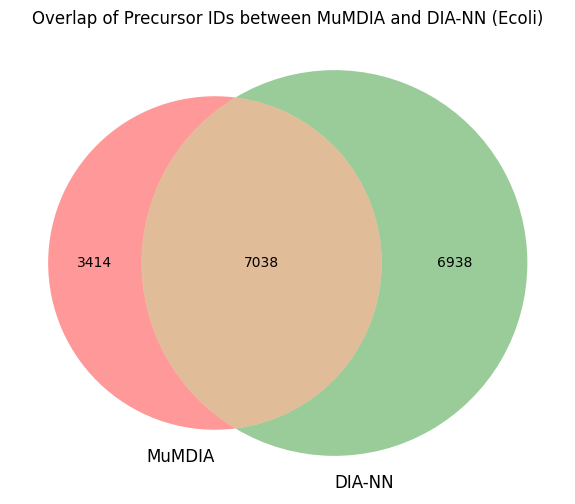

In [100]:
from matplotlib_venn import venn2

# Create a venn diagram of identifications
import matplotlib.pyplot as plt

mumdia_precursor_ids = set(mumdia_astral_valid["Precursor.Id"])
diann_precursor_ids = set(diann_astral["Precursor.Id"])

plt.figure(figsize=(8, 6))
venn2([mumdia_precursor_ids, diann_precursor_ids], set_labels=("MuMDIA", "DIA-NN"))
plt.title("Overlap of Precursor IDs between MuMDIA and DIA-NN (Ecoli)")
plt.show()

In [102]:
diann_not_mumdia = diann_astral[
    ~diann_astral["Precursor.Id"].isin(mumdia_astral_valid["Precursor.Id"])
]
mumdia_not_diann = mumdia_astral_valid[
    ~mumdia_astral_valid["Precursor.Id"].isin(diann_astral["Precursor.Id"])
]

In [104]:
diann_not_mumdia["Precursor.Id"]

1        AAAAPVTGPLADDPIQETITFDDFAK3
2                          AAAAVLAK1
5                  AAAEADDIFGELSSGK2
7             AAAEVGAPFIEIHTGCYADAK3
11                         AAAIAYAR2
                    ...             
13965                    YYGFDIGGTK2
13967              YYGYVTQPWFIGHSQR3
13968            YYLATGGGDISQAEVLLK2
13973                    YYPGSPLIAR2
13975                 YYSVIYNLIDEVK2
Name: Precursor.Id, Length: 6938, dtype: object

In [105]:
mumdia_not_diann["Precursor.Id"]

0              VAVVLGESEVANGTAVVK4
2        ANAVVM[Oxidation]ATGGAGR3
6               PFVLGPTHEEVITDLIR2
9                 HLNATIINEGDINTR4
13              DANGNLLADGDSVTIIK3
                   ...            
10445                     ADDIQIR1
10446       SIGTLSAFEQNALEGMLDTLK4
10447       SIGTLSAFEQNALEGMLDTLK3
10448                  FGLPIYVPER3
10451          VLQM[Oxidation]LEK1
Name: Precursor.Id, Length: 3414, dtype: object